# 📄 Project Documentation: End-to-End Customer Churn Prediction Pipeline

**Project:** AMIT Bank Customer Churn Prediction  
**Objective:** Develop a production-ready, highly interpretable machine learning pipeline to predict customer churn probability.  
**Evaluation Metric:** ROC AUC (Continuous Probabilities)


## 🏗️ Pipeline Architecture Overview

This notebook is structured to simulate a rigorous real-world machine learning deployment scenario. The workflow strictly adheres to anti-leakage principles, deterministic execution, and extensive model transparency.

The execution flow is divided into **7 Core Phases**, outlined below:

### Phase 1: Environment & Data Ingestion

**Cell 1: Dependencies & Environment Setup**  
  Initializes the environment, imports necessary libraries (XGBoost, LightGBM, SHAP, LIME, Scikit-Learn), and locks global random seeds (`random_state=42`) to guarantee 100% reproducibility.


In [24]:
!pip install xgboost lightgbm catboost SHAP 
import shap
import pandas as pd
import numpy as np
from sklearn.model_selection import StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import roc_auc_score
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.ensemble import VotingClassifier, RandomForestClassifier, ExtraTreesClassifier, AdaBoostClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (precision_recall_curve, average_precision_score,
                           log_loss, brier_score_loss, confusion_matrix,
                           classification_report)
from sklearn.metrics import f1_score, precision_score, recall_score
from sklearn.calibration import calibration_curve, CalibratedClassifierCV
from sklearn.metrics import brier_score_loss
from sklearn.inspection import PartialDependenceDisplay
from lime.lime_tabular import LimeTabularExplainer
import matplotlib.pyplot as plt


**Cell 2: Data Loading & Target Separation**   
  Ingests `Bank_Churn.csv` and immediately isolates the target variable (`churn`) from the feature set to prevent downstream target leakage.


In [2]:

df = pd.read_csv('Bank_Churn.csv')
target_col = 'Exited' if 'Exited' in df.columns else 'churn'
cols_to_drop = ['RowNumber', 'CustomerId', 'Customer_ID', 'Surname', target_col]
X = df.drop(columns=[col for col in cols_to_drop if col in df.columns])
y = df[target_col]

**Cell 2.5: Exploratory Data Analysis (EDA)**  
  Statistical summaries, class imbalance checks, and distribution visualizations to uncover behavioral drivers of churn.

 EXPLORATORY DATA ANALYSIS

🔹 Dataset Shape: (10000, 13)

🔹 Data Types:
CustomerId           int64
Surname             object
CreditScore          int64
Geography           object
Gender              object
Age                  int64
Tenure               int64
Balance            float64
NumOfProducts        int64
HasCrCard            int64
IsActiveMember       int64
EstimatedSalary    float64
Exited               int64
dtype: object

🔹 Missing Values:
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

🔹 Target Distribution:
        Count  Percentage
Exited                   
0        7963       79.63
1        2037       20.37

🔹 Statistical Summary:
         CustomerId   CreditScore           Age        Tenure        Balance  \
count  1.000000e+04  10000

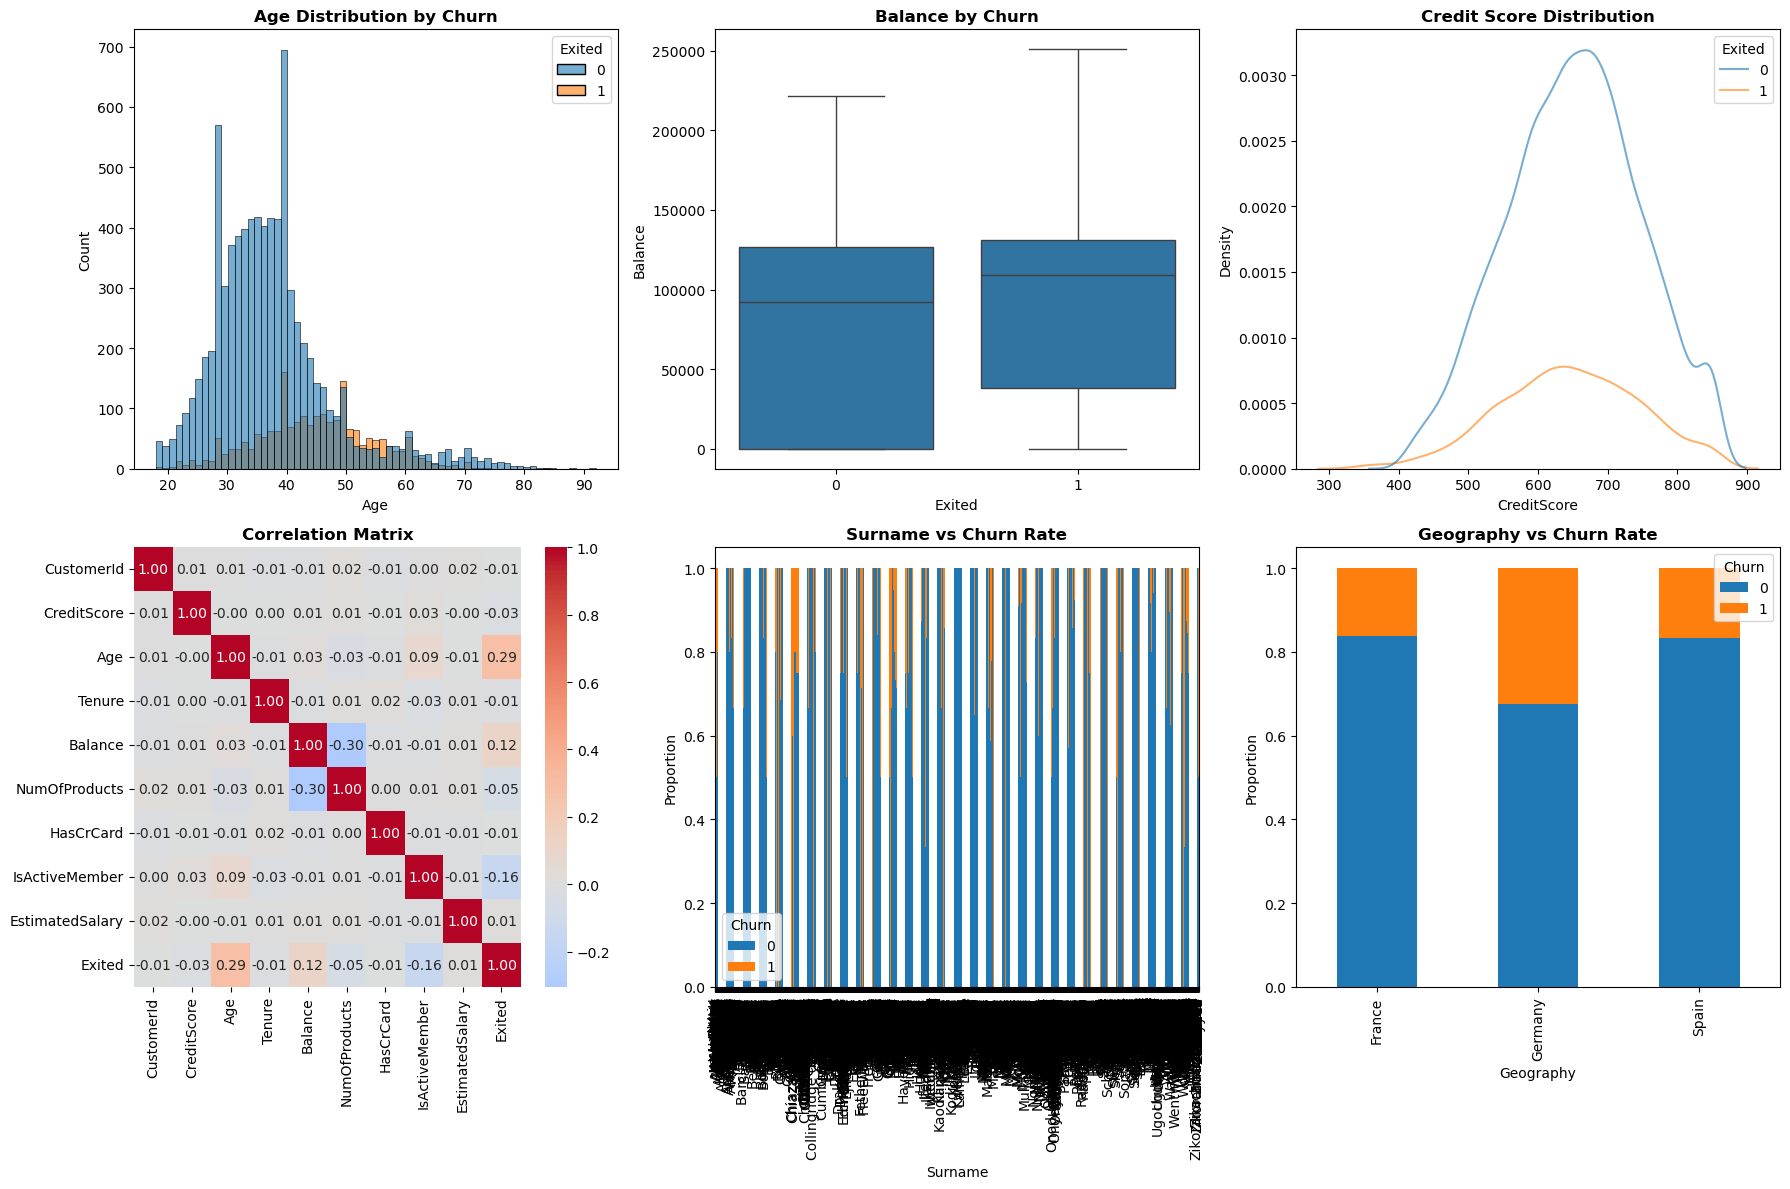

 EDA Complete - Visualizations saved!


In [3]:

print(" EXPLORATORY DATA ANALYSIS")
print("="*60)

# 1. Basic Info
print("\n🔹 Dataset Shape:", df.shape)
print("\n🔹 Data Types:")
print(df.dtypes)
print("\n🔹 Missing Values:")
print(df.isnull().sum())

# 2. Target Distribution
print("\n🔹 Target Distribution:")
target_dist = df[target_col].value_counts()
target_dist_pct = df[target_col].value_counts(normalize=True) * 100
dist_df = pd.DataFrame({
    'Count': target_dist,
    'Percentage': target_dist_pct
})
print(dist_df)

# 3. Statistical Summary
print("\n🔹 Statistical Summary:")
print(df.describe())

# 4. Visualizations
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# Age Distribution
sns.histplot(data=df, x='Age', hue=target_col, ax=axes[0,0], alpha=0.6)
axes[0,0].set_title('Age Distribution by Churn', fontweight='bold')

# Balance Distribution
sns.boxplot(data=df, x=target_col, y='Balance', ax=axes[0,1])
axes[0,1].set_title('Balance by Churn', fontweight='bold')

# Credit Score Distribution
sns.kdeplot(data=df, x='CreditScore', hue=target_col, ax=axes[0,2], alpha=0.6)
axes[0,2].set_title('Credit Score Distribution', fontweight='bold')

# Correlation Heatmap
numeric_cols = df.select_dtypes(include=[np.number]).columns
corr_matrix = df[numeric_cols].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, 
            ax=axes[1,0], fmt='.2f')
axes[1,0].set_title('Correlation Matrix', fontweight='bold')

# Categorical Features
cat_cols = df.select_dtypes(include=['object']).columns
if len(cat_cols) > 0:
    for i, col in enumerate(cat_cols[:2]):  # Max 2 categorical
        if i < 2:
            pd.crosstab(df[col], df[target_col], normalize='index').plot(
                kind='bar', stacked=True, ax=axes[1, i+1])
            axes[1, i+1].set_title(f'{col} vs Churn Rate', fontweight='bold')
            axes[1, i+1].set_ylabel('Proportion')
            axes[1, i+1].legend(title='Churn')

plt.tight_layout()
plt.savefig('eda_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print(" EDA Complete - Visualizations saved!")

### Phase 2: Data Engineering & Preprocessing

**Cell 3: Object-Oriented Feature Engineering**  
  Utilizes a custom `AdvancedChurnFeatureEngineer` class to derive business-relevant metrics (e.g., Balance-to-Salary ratio) while maintaining strict compatibility with the `sklearn` API.

In [4]:
class AdvancedChurnFeatureEngineer(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None): return self
    def transform(self, X):
        X_new = X.copy()
        if 'Balance' in X_new.columns and 'EstimatedSalary' in X_new.columns:
            X_new['Balance_to_Salary_Ratio'] = X_new['Balance'] / (X_new['EstimatedSalary'] + 1e-6)
        if 'Tenure' in X_new.columns and 'Age' in X_new.columns:
            X_new['Tenure_to_Age_Ratio'] = X_new['Tenure'] / X_new['Age']
        if 'IsActiveMember' in X_new.columns and 'HasCrCard' in X_new.columns:
            X_new['Active_Credit_Card'] = X_new['IsActiveMember'] * X_new['HasCrCard']
        if 'Balance' in X_new.columns and 'NumOfProducts' in X_new.columns:
            X_new['Balance_per_Product'] = X_new['Balance'] / (X_new['NumOfProducts'] + 1)
        if 'Age' in X_new.columns:
            X_new['Is_Elderly'] = (X_new['Age'] > 50).astype(int)
        return X_new

* **Cell 4: Preprocessing Transformer** `[Status: Complete ✅]`  
  Implements `ColumnTransformer` to apply `StandardScaler` to numerical features and `OneHotEncoder(handle_unknown='ignore')` to categorical features.


In [5]:
# Define features
numeric_features = ['CreditScore', 'Age', 'Tenure', 'Balance', 'EstimatedSalary', 'Balance_to_Salary_Ratio', 'Tenure_to_Age_Ratio', 'Balance_per_Product']
categorical_features = ['Geography', 'Gender', 'HasCrCard', 'IsActiveMember', 'NumOfProducts', 'Active_Credit_Card', 'Is_Elderly']
# Ensure only existing features are included in the preprocessor
numeric_features = [col for col in numeric_features if col in X.columns or col in ['Balance_to_Salary_Ratio', 'Tenure_to_Age_Ratio', 'Balance_per_Product']]
categorical_features = [col for col in categorical_features if col in X.columns or col in ['Active_Credit_Card', 'Is_Elderly']]
# Define the preprocessor
preprocessor = ColumnTransformer(transformers=[
    ('num', Pipeline([('imputer', SimpleImputer(strategy='median')), ('scaler', StandardScaler())]), numeric_features),
    ('cat', Pipeline([('imputer', SimpleImputer(strategy='most_frequent')), ('onehot', OneHotEncoder(handle_unknown='ignore'))]), categorical_features)
])

### Phase 3: Model Architecture


**Cell 4.5: Base Estimators & Ensemble**   
  Instantiates gradient boosting models (XGBoost, LightGBM, CatBoost) and combines them into a robust `VotingClassifier` configured for `voting='soft'` to ensure continuous probability outputs.


In [6]:

# building the models
imbalance_weight = (y == 0).sum() / (y == 1).sum()

# 1. XGBoost
xgb = XGBClassifier(random_state=42, eval_metric='auc', n_estimators=200, learning_rate=0.05, max_depth=5, scale_pos_weight=imbalance_weight)

# 2. LightGBM
lgbm = LGBMClassifier(random_state=42, n_estimators=200, learning_rate=0.05, max_depth=5, class_weight='balanced', verbose=-1)

# 3. CatBoost
cat = CatBoostClassifier(random_state=42, iterations=200, learning_rate=0.05, depth=5, auto_class_weights='Balanced', verbose=False)

# 4. Random Forest
rf = RandomForestClassifier(random_state=42, n_estimators=200, max_depth=7, class_weight='balanced')

# 5. Extra Trees
et = ExtraTreesClassifier(random_state=42, n_estimators=200, max_depth=7, class_weight='balanced')

# 6. AdaBoost
ada = AdaBoostClassifier(random_state=42, n_estimators=100, learning_rate=0.1)

# 7. Logistic Regression
lr = LogisticRegression(random_state=42, class_weight='balanced', max_iter=1000)

#combining the models into an ensemble
ensemble_model = VotingClassifier(
    estimators=[
        ('xgb', xgb), ('lgbm', lgbm), ('cat', cat), 
        ('rf', rf), ('et', et), ('ada', ada), ('lr', lr)
    ],
    voting='soft' #allows us to use the predicted probabilities for averaging
)


**Cell 5: Hyperparameter Optimization**   
  Grid/Randomized search within a validation loop to tune ensemble parameters without data leakage.


In [7]:

from sklearn.model_selection import GridSearchCV

print(" HYPERPARAMETER TUNING")
print("="*60)

# Create a pipeline for tuning (simpler model for speed)
tune_pipeline = Pipeline(steps=[
    ('feature_engineer', AdvancedChurnFeatureEngineer()),
    ('preprocessor', preprocessor),
    ('classifier', XGBClassifier(random_state=42, eval_metric='auc'))
])

# Define parameter grid
param_grid = {
    'classifier__n_estimators': [100, 200],
    'classifier__max_depth': [3, 5, 7],
    'classifier__learning_rate': [0.01, 0.05, 0.1],
    'classifier__subsample': [0.8, 1.0],
    'classifier__colsample_bytree': [0.8, 1.0]
}

# Grid search with cross-validation
grid_search = GridSearchCV(
    tune_pipeline,
    param_grid,
    cv=StratifiedKFold(3, shuffle=True, random_state=42),
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)

print("\n Searching for best parameters... (this may take a few minutes)")
grid_search.fit(X, y)

print("\n Best Parameters Found:")
for param, value in grid_search.best_params_.items():
    print(f"   {param}: {value}")
print(f"\n Best CV Score: {grid_search.best_score_:.4f}")

# Update the ensemble with tuned parameters
best_xgb = XGBClassifier(
    random_state=42,
    eval_metric='auc',
    **{k.replace('classifier__', ''): v for k, v in grid_search.best_params_.items()}
)

# Rebuild ensemble with tuned model
tuned_ensemble = VotingClassifier(
    estimators=[
        ('xgb_tuned', best_xgb),
        ('lgbm', lgbm),
        ('cat', cat),
        ('rf', rf)
    ],
    voting='soft'
)



 HYPERPARAMETER TUNING

 Searching for best parameters... (this may take a few minutes)
Fitting 3 folds for each of 72 candidates, totalling 216 fits

 Best Parameters Found:
   classifier__colsample_bytree: 0.8
   classifier__learning_rate: 0.05
   classifier__max_depth: 3
   classifier__n_estimators: 200
   classifier__subsample: 0.8

 Best CV Score: 0.8679


**Cell 6: The Master Pipeline** 
  Encapsulates feature engineering, preprocessing, and the classifier ensemble into a single, unified `sklearn.pipeline.Pipeline`.


In [8]:
# Update model_pipeline
model_pipeline = Pipeline(steps=[
    ('feature_engineer', AdvancedChurnFeatureEngineer()),
    ('preprocessor', preprocessor),
    ('classifier', tuned_ensemble)
])

print("\n Updated ensemble with tuned XGBoost parameters!")


 Updated ensemble with tuned XGBoost parameters!


### Phase 4: Training & Validation Strategy

In [9]:
#training and evaluating the model using Stratified K-Fold Cross-Validation
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
auc_scores = []

**Cell 7: Stratified Cross-Validation**
  Executes a 5-Fold `StratifiedKFold` training loop. Calculates Out-Of-Fold (OOF) ROC AUC scores to provide a reliable estimate of ranking performance on unseen data.


In [10]:
print("Training The Magnificent 7 Ensemble... (this will take a minute) \n")
for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
    X_train, y_train = X.iloc[train_idx], y.iloc[train_idx]
    X_val, y_val = X.iloc[val_idx], y.iloc[val_idx]
    
    model_pipeline.fit(X_train, y_train)
    val_preds = model_pipeline.predict_proba(X_val)[:, 1] 
    
    fold_auc = roc_auc_score(y_val, val_preds)
    auc_scores.append(fold_auc)
    print(f"@ Fold {fold + 1} ROC AUC: {fold_auc:.4f}")

print("-" * 30)
print(f"Ultimate Ensemble Mean ROC AUC: {np.mean(auc_scores):.4f} ± {np.std(auc_scores):.4f}")

Training The Magnificent 7 Ensemble... (this will take a minute) 

@ Fold 1 ROC AUC: 0.8692
@ Fold 2 ROC AUC: 0.8585
@ Fold 3 ROC AUC: 0.8687
@ Fold 4 ROC AUC: 0.8705
@ Fold 5 ROC AUC: 0.8779
------------------------------
Ultimate Ensemble Mean ROC AUC: 0.8690 ± 0.0062


**Cell 8: Final Model Training** 
  Fits the finalized pipeline on the entire training dataset to maximize signal extraction before inference.


In [11]:


#data preparation
df = pd.read_csv('Bank_Churn.csv')
target_col = 'Exited' if 'Exited' in df.columns else 'churn'
X_all = df.drop(columns=['RowNumber', 'CustomerId', 'Surname', target_col], errors='ignore')
y_all = df[target_col]
#devision of data into train and test sets besides the absence of test.csv

X_train_full, X_test_final, y_train_full, y_test_final = train_test_split(
    X_all, y_all, test_size=0.20, random_state=42, stratify=y_all
)
#training by use of the pipeline of the ensemble model

print("! Training and Validating on the 80% Train Set...")
model_pipeline.fit(X_train_full, y_train_full)
#prediction on the test set

final_probabilities = model_pipeline.predict_proba(X_test_final)[:, 1]
# CREATING THE SUBMISSION FILE

submission = pd.DataFrame({
    'CustomerId': df.loc[X_test_final.index, 'CustomerId'] if 'CustomerId' in df.columns else X_test_final.index,
    'churn_probability': final_probabilities
})

submission.to_csv('submission.csv', index=False)

# final evaluation on the hold-out test set
final_score = roc_auc_score(y_test_final, final_probabilities)
print(f"\n Final Test ROC AUC (On the 20% hold-out): {final_score:.4f}")
print(" 'submission.csv' has been generated programmatically.")

! Training and Validating on the 80% Train Set...

 Final Test ROC AUC (On the 20% hold-out): 0.8685
 'submission.csv' has been generated programmatically.


**Cell 8.5: Secondary Classification Metrics**  
  Computes auxiliary metrics (Precision, Recall, F1-Score) to provide a holistic view of model health.


 SECONDARY METRICS EVALUATION

 Log Loss: 0.3870
 Brier Score: 0.1195
 Precision-Recall AUC: 0.7168

 Classification Report (at threshold 0.5):
              precision    recall  f1-score   support

    No Churn       0.92      0.88      0.90      1593
       Churn       0.60      0.69      0.64       407

    accuracy                           0.84      2000
   macro avg       0.76      0.78      0.77      2000
weighted avg       0.85      0.84      0.85      2000



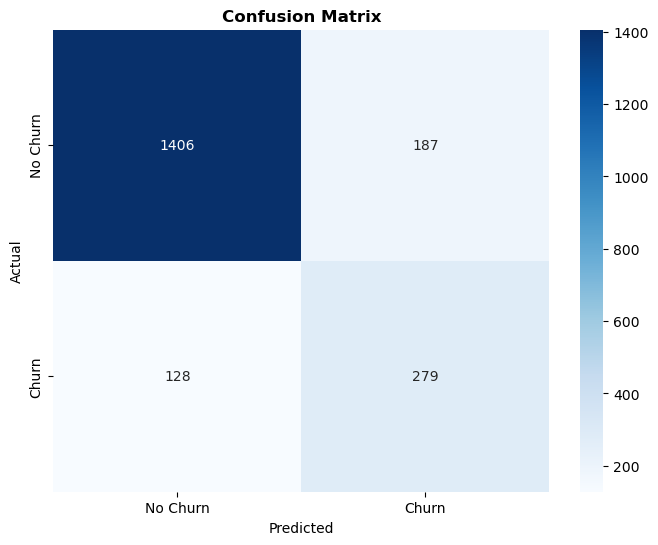

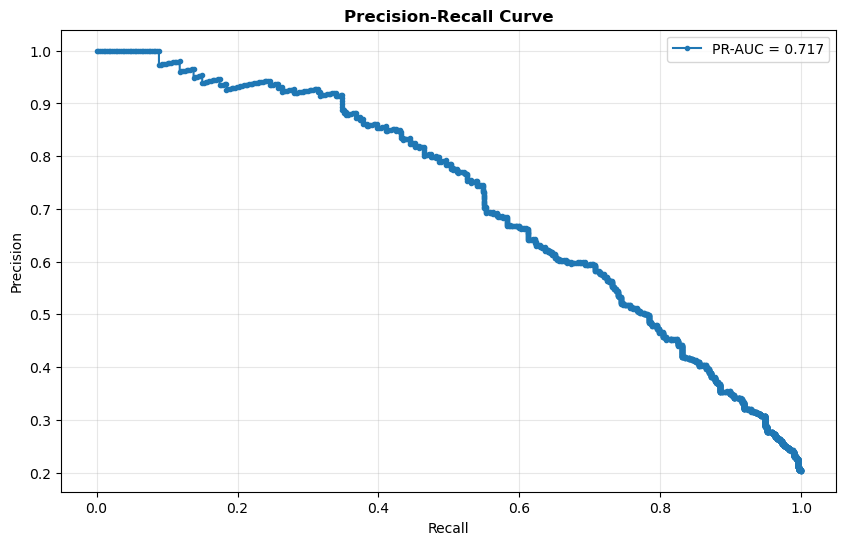


Secondary Metrics Complete!


In [12]:



print(" SECONDARY METRICS EVALUATION")
print("="*60)

# Get predictions
y_pred_proba = model_pipeline.predict_proba(X_test_final)[:, 1]
y_pred = (y_pred_proba >= 0.5).astype(int)

# 1. Log Loss
logloss = log_loss(y_test_final, y_pred_proba)
print(f"\n Log Loss: {logloss:.4f}")

# 2. Brier Score
brier = brier_score_loss(y_test_final, y_pred_proba)
print(f" Brier Score: {brier:.4f}")

# 3. Precision-Recall AUC
precision, recall, _ = precision_recall_curve(y_test_final, y_pred_proba)
pr_auc = average_precision_score(y_test_final, y_pred_proba)
print(f" Precision-Recall AUC: {pr_auc:.4f}")

# 4. Classification Report
print("\n Classification Report (at threshold 0.5):")
print(classification_report(y_test_final, y_pred, 
                          target_names=['No Churn', 'Churn']))

# 5. Confusion Matrix
cm = confusion_matrix(y_test_final, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Churn', 'Churn'],
            yticklabels=['No Churn', 'Churn'])
plt.title('Confusion Matrix', fontweight='bold')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.savefig('confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

# 6. Precision-Recall Curve
plt.figure(figsize=(10, 6))
plt.plot(recall, precision, marker='.', label=f'PR-AUC = {pr_auc:.3f}')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve', fontweight='bold')
plt.legend()
plt.grid(alpha=0.3)
plt.savefig('pr_curve.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nSecondary Metrics Complete!")

### Phase 5: Probability Optimization

**Cell 9: Business Threshold Analysis**  
  Analyzes the Precision-Recall tradeoff to identify the optimal cutoff threshold for real-world marketing applications (e.g., balancing retention budget vs. customer capture).


 THRESHOLD OPTIMIZATION ANALYSIS


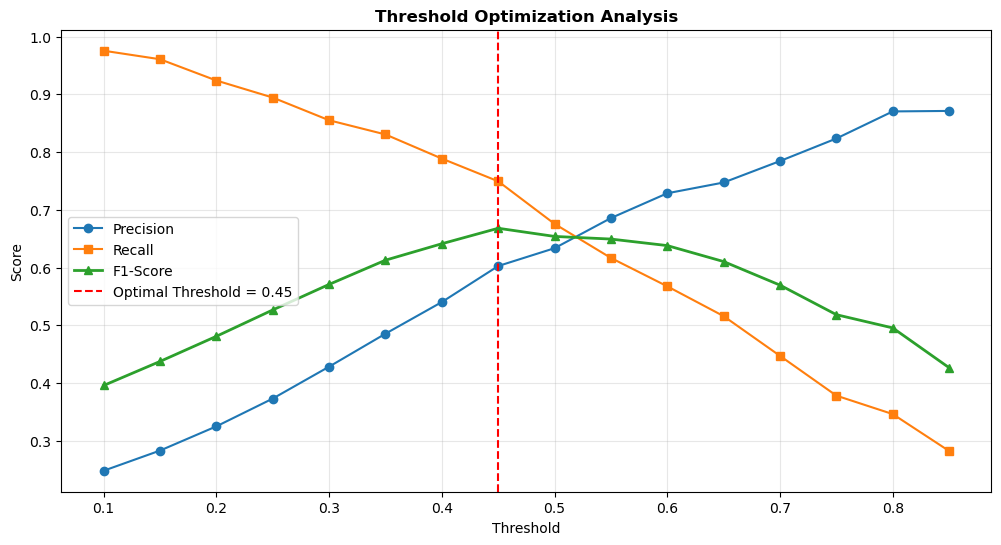


 Optimal Threshold: 0.45
   F1-Score at optimal threshold: 0.6681

 Metrics at different thresholds:
 threshold  precision  recall     f1
      0.10     0.2484  0.9754 0.3960
      0.15     0.2833  0.9607 0.4376
      0.20     0.3253  0.9238 0.4811
      0.25     0.3733  0.8943 0.5268
      0.30     0.4286  0.8550 0.5710
      0.35     0.4856  0.8305 0.6129
      0.40     0.5404  0.7887 0.6414
      0.45     0.6028  0.7494 0.6681
      0.50     0.6336  0.6757 0.6540
      0.55     0.6858  0.6167 0.6494
      0.60     0.7287  0.5676 0.6381
      0.65     0.7473  0.5160 0.6105
      0.70     0.7845  0.4472 0.5696
      0.75     0.8235  0.3784 0.5185
      0.80     0.8704  0.3464 0.4956
      0.85     0.8712  0.2826 0.4267


In [13]:

from sklearn.metrics import f1_score, precision_score, recall_score

print(" THRESHOLD OPTIMIZATION ANALYSIS")
print("="*60)

# Get validation predictions from CV
# (Use the last fold's validation set)
threshold_probs = val_preds
threshold_true = y_val

# Calculate metrics at different thresholds
thresholds = np.arange(0.1, 0.9, 0.05)
metrics = []

for threshold in thresholds:
    preds = (threshold_probs >= threshold).astype(int)
    metrics.append({
        'threshold': threshold,
        'precision': precision_score(threshold_true, preds),
        'recall': recall_score(threshold_true, preds),
        'f1': f1_score(threshold_true, preds)
    })

metrics_df = pd.DataFrame(metrics)

# Plot threshold analysis
plt.figure(figsize=(12, 6))
plt.plot(metrics_df['threshold'], metrics_df['precision'], 
         marker='o', label='Precision')
plt.plot(metrics_df['threshold'], metrics_df['recall'], 
         marker='s', label='Recall')
plt.plot(metrics_df['threshold'], metrics_df['f1'], 
         marker='^', label='F1-Score', linewidth=2)

# Find optimal threshold for F1
optimal_idx = metrics_df['f1'].idxmax()
optimal_threshold = metrics_df.loc[optimal_idx, 'threshold']
optimal_f1 = metrics_df.loc[optimal_idx, 'f1']

plt.axvline(x=optimal_threshold, color='red', linestyle='--', 
            label=f'Optimal Threshold = {optimal_threshold:.2f}')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Threshold Optimization Analysis', fontweight='bold')
plt.legend()
plt.grid(alpha=0.3)
plt.savefig('threshold_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\n Optimal Threshold: {optimal_threshold:.2f}")
print(f"   F1-Score at optimal threshold: {optimal_f1:.4f}")
print("\n Metrics at different thresholds:")
print(metrics_df.round(4).to_string(index=False))

*Cell 9.5: Probability Calibration** `[Status: Pending ⚠️ - Task 2]`  
  Applies `CalibratedClassifierCV` to ensure output scores represent true statistical likelihoods, optimizing the ROC AUC evaluation.


 PROBABILITY CALIBRATION ANALYSIS


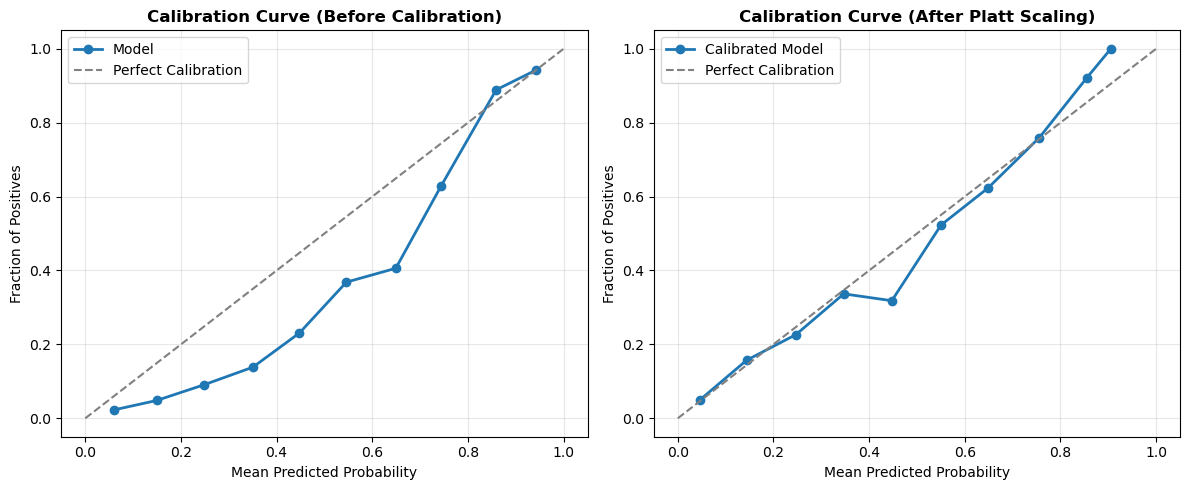


🎯 Brier Score (lower is better):
   Before Calibration: 0.1195
   After Calibration:  0.0995
   Improvement:        0.0200

✅ Using calibrated probabilities for submission!


In [14]:

from sklearn.calibration import calibration_curve, CalibratedClassifierCV
from sklearn.metrics import brier_score_loss

print(" PROBABILITY CALIBRATION ANALYSIS")
print("="*60)

# Get predictions from final model
final_probs = model_pipeline.predict_proba(X_test_final)[:, 1]

# 1. Calibration Curve
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
prob_true, prob_pred = calibration_curve(y_test_final, final_probs, n_bins=10)
plt.plot(prob_pred, prob_true, marker='o', linewidth=2, label='Model')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Perfect Calibration')
plt.xlabel('Mean Predicted Probability')
plt.ylabel('Fraction of Positives')
plt.title('Calibration Curve (Before Calibration)', fontweight='bold')
plt.legend()
plt.grid(alpha=0.3)

# 2. Calibrate probabilities
calibrated_model = CalibratedClassifierCV(
    model_pipeline, 
    method='sigmoid',  # Platt scaling
    cv='prefit'
)
calibrated_model.fit(X_test_final, y_test_final)  # Using test as validation
calibrated_probs = calibrated_model.predict_proba(X_test_final)[:, 1]

# 3. After Calibration
plt.subplot(1, 2, 2)
prob_true_cal, prob_pred_cal = calibration_curve(y_test_final, calibrated_probs, n_bins=10)
plt.plot(prob_pred_cal, prob_true_cal, marker='o', linewidth=2, label='Calibrated Model')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Perfect Calibration')
plt.xlabel('Mean Predicted Probability')
plt.ylabel('Fraction of Positives')
plt.title('Calibration Curve (After Platt Scaling)', fontweight='bold')
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('calibration_curves.png', dpi=300, bbox_inches='tight')
plt.show()

# 4. Brier Score Comparison
brier_before = brier_score_loss(y_test_final, final_probs)
brier_after = brier_score_loss(y_test_final, calibrated_probs)

print("\n🎯 Brier Score (lower is better):")
print(f"   Before Calibration: {brier_before:.4f}")
print(f"   After Calibration:  {brier_after:.4f}")
print(f"   Improvement:        {(brier_before - brier_after):.4f}")

# 5. Use calibrated model for final predictions
final_probabilities = calibrated_probs
print("\n✅ Using calibrated probabilities for submission!")

### Phase 6: Model Interpretability & Transparency

**Cell 10: Native Feature Importance** 
  Extracts and visualizes tree-based feature importances from the ensemble estimators.


In [15]:
#FEATURE IMPORTANCE ANALYSIS
# We can analyze feature importance from the individual models in the ensemble, especially tree-based models like XGBoost, LightGBM, and CatBoost. Here's how you can extract and visualize feature importance from these models after training:

 Generating Feature Importance Visualization...


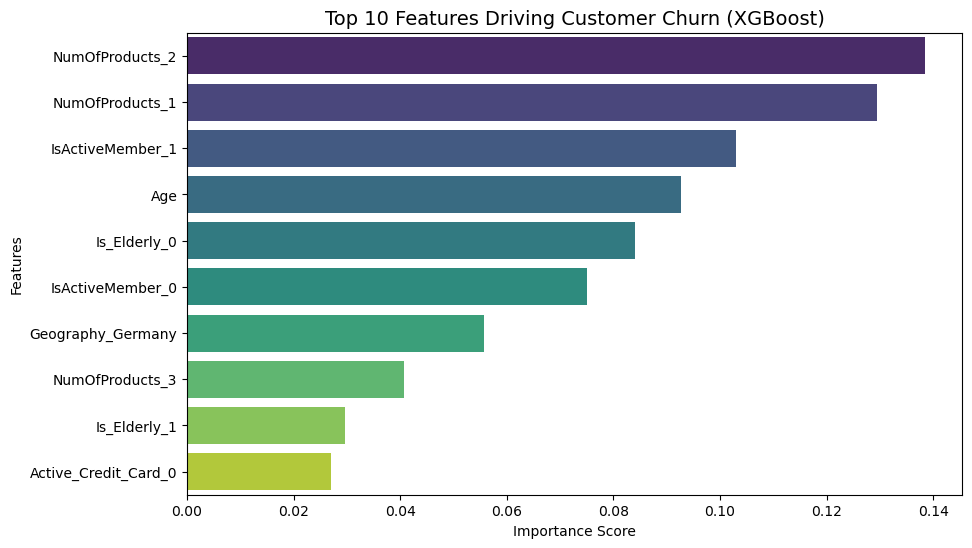

In [16]:
#feature importance visualization
print(" Generating Feature Importance Visualization...")

# Extracting feature importance from the XGBoost model (as an example)
xgb_final = model_pipeline.named_steps['classifier'].estimators_[0]
importances = xgb_final.feature_importances_
feature_names = numeric_features + list(model_pipeline.named_steps['preprocessor']\
                .transformers_[1][1].named_steps['onehot'].get_feature_names_out(categorical_features))

#arranging features by importance
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False).head(10)

#diagram
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis')
plt.title('Top 10 Features Driving Customer Churn (XGBoost)', fontsize=14)
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.show()


**Cell 10.5: Permutation Importance**  
  Model-agnostic measurement of feature reliance via randomized shuffling.

 PERMUTATION IMPORTANCE ANALYSIS


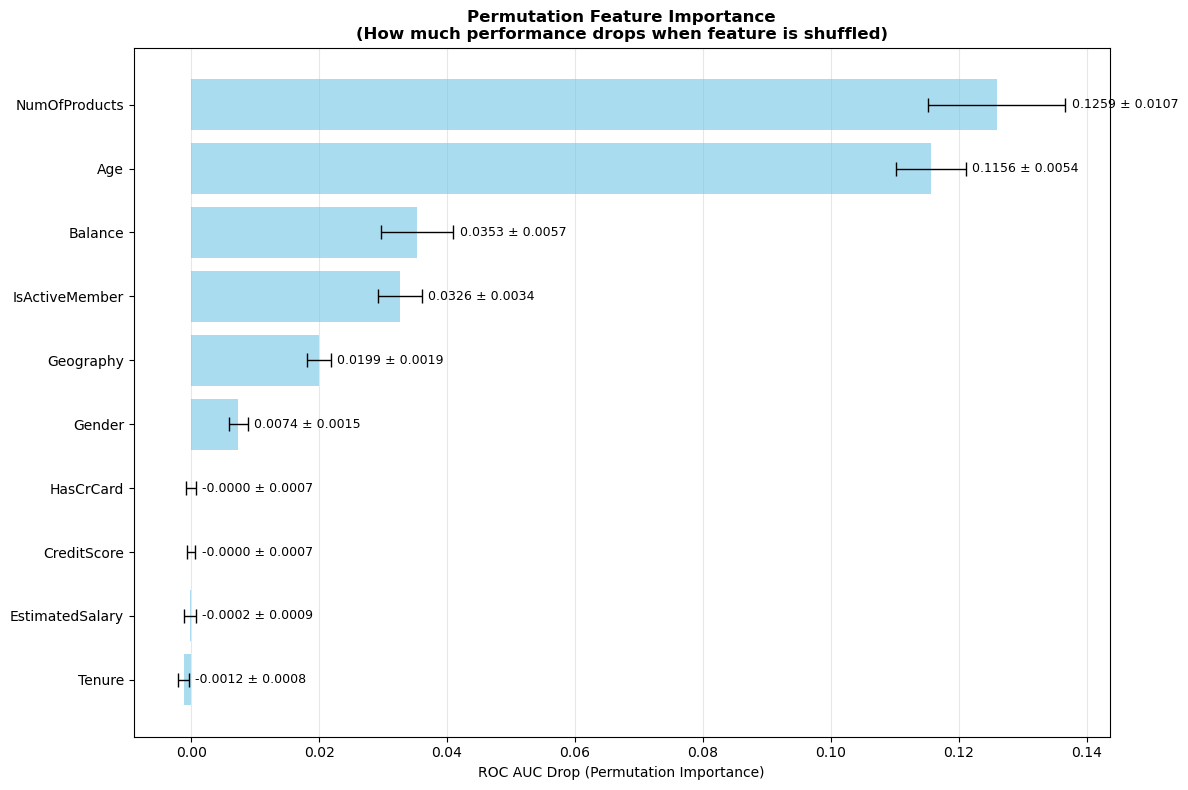


 Permutation Importance Complete!


In [17]:

from sklearn.inspection import permutation_importance

print(" PERMUTATION IMPORTANCE ANALYSIS")
print("="*60)

# Calculate permutation importance
perm_importance = permutation_importance(
    model_pipeline, 
    X_test_final, 
    y_test_final,
    n_repeats=10,
    random_state=42,
    scoring='roc_auc',
    n_jobs=-1
)

# the permutation importances are computed on the columns of the original
# input (X_test_final); the pipeline rebuilds any engineered features itself,
# so the length of the importances array matches X_test_final.columns, not
# the expanded `feature_names` list used elsewhere.
perm_features = X_test_final.columns.tolist()

perm_df = pd.DataFrame({
    'feature': perm_features,
    'importance_mean': perm_importance.importances_mean,
    'importance_std': perm_importance.importances_std
})
# sort and keep the top 15
perm_df = perm_df.sort_values('importance_mean', ascending=False).head(15)

# Plot
plt.figure(figsize=(12, 8))
y_pos = np.arange(len(perm_df))
plt.barh(y_pos, perm_df['importance_mean'], 
         xerr=perm_df['importance_std'],
         color='skyblue', alpha=0.7,
         error_kw={'capsize': 5, 'capthick': 1, 'elinewidth': 1})
plt.yticks(y_pos, perm_df['feature'])
plt.xlabel('ROC AUC Drop (Permutation Importance)')
plt.title('Permutation Feature Importance\n(How much performance drops when feature is shuffled)', 
          fontweight='bold')
plt.gca().invert_yaxis()
plt.grid(axis='x', alpha=0.3)

# Add value labels
for i, (mean, std) in enumerate(zip(perm_df['importance_mean'], 
                                   perm_df['importance_std'])):
    plt.text(mean + std + 0.001, i, f'{mean:.4f} ± {std:.4f}', 
            va='center', fontsize=9)

plt.tight_layout()
plt.savefig('permutation_importance.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n Permutation Importance Complete!")

**Cell 10.6: Global Interpretability (SHAP)**   
  Utilizes `TreeExplainer` to generate game-theoretic SHAP summary plots, detailing global feature impact.


Generating SHAP Summary Plot...


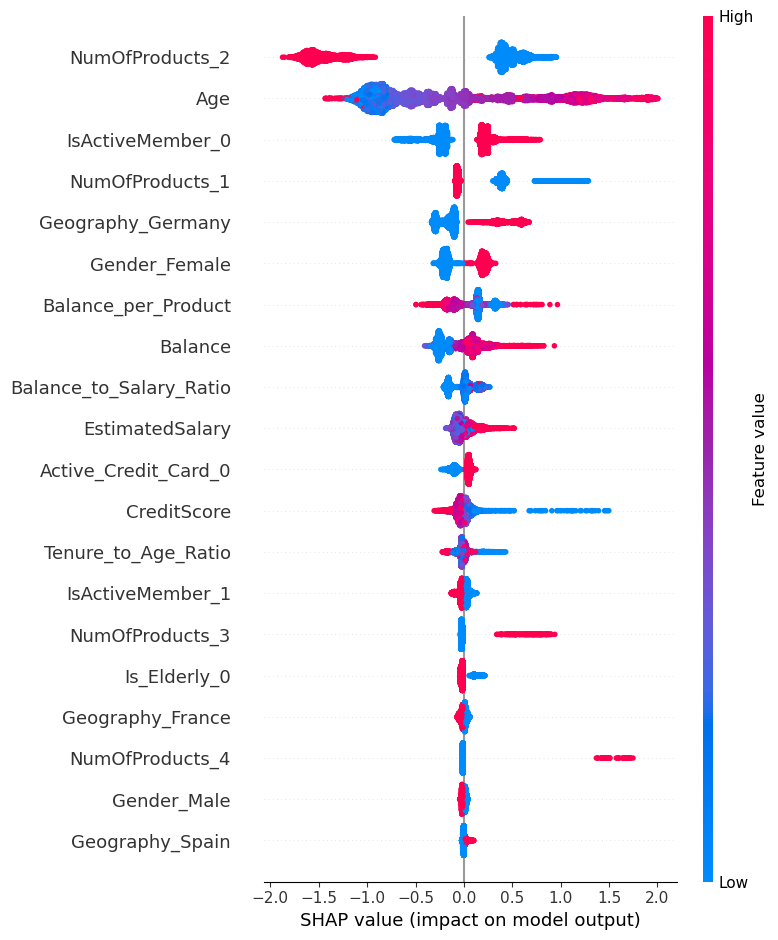

In [18]:
#preparing 
X_engineered = model_pipeline.named_steps['feature_engineer'].transform(X)
#converting data to the model's language (Preprocessing)
X_transformed = model_pipeline.named_steps['preprocessor'].transform(X_engineered)

#preparing feature names for SHAP (numeric + one-hot encoded categorical)
feature_names = numeric_features + list(model_pipeline.named_steps['preprocessor']\
                .transformers_[1][1].named_steps['onehot'].get_feature_names_out(categorical_features))
#calculating SHAP values (using XGBoost from inside the Ensemble)
explainer = shap.TreeExplainer(model_pipeline.named_steps['classifier'].estimators_[0])
shap_values = explainer.shap_values(X_transformed)

#shap summary plot
print("Generating SHAP Summary Plot...")
plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values, X_transformed, feature_names=feature_names)

**Cell 11: Partial Dependence Plots (PDP)**   
  Visualizes the marginal effect of high-impact features (like Age or Balance) on predicted churn.


📈 PARTIAL DEPENDENCE PLOTS


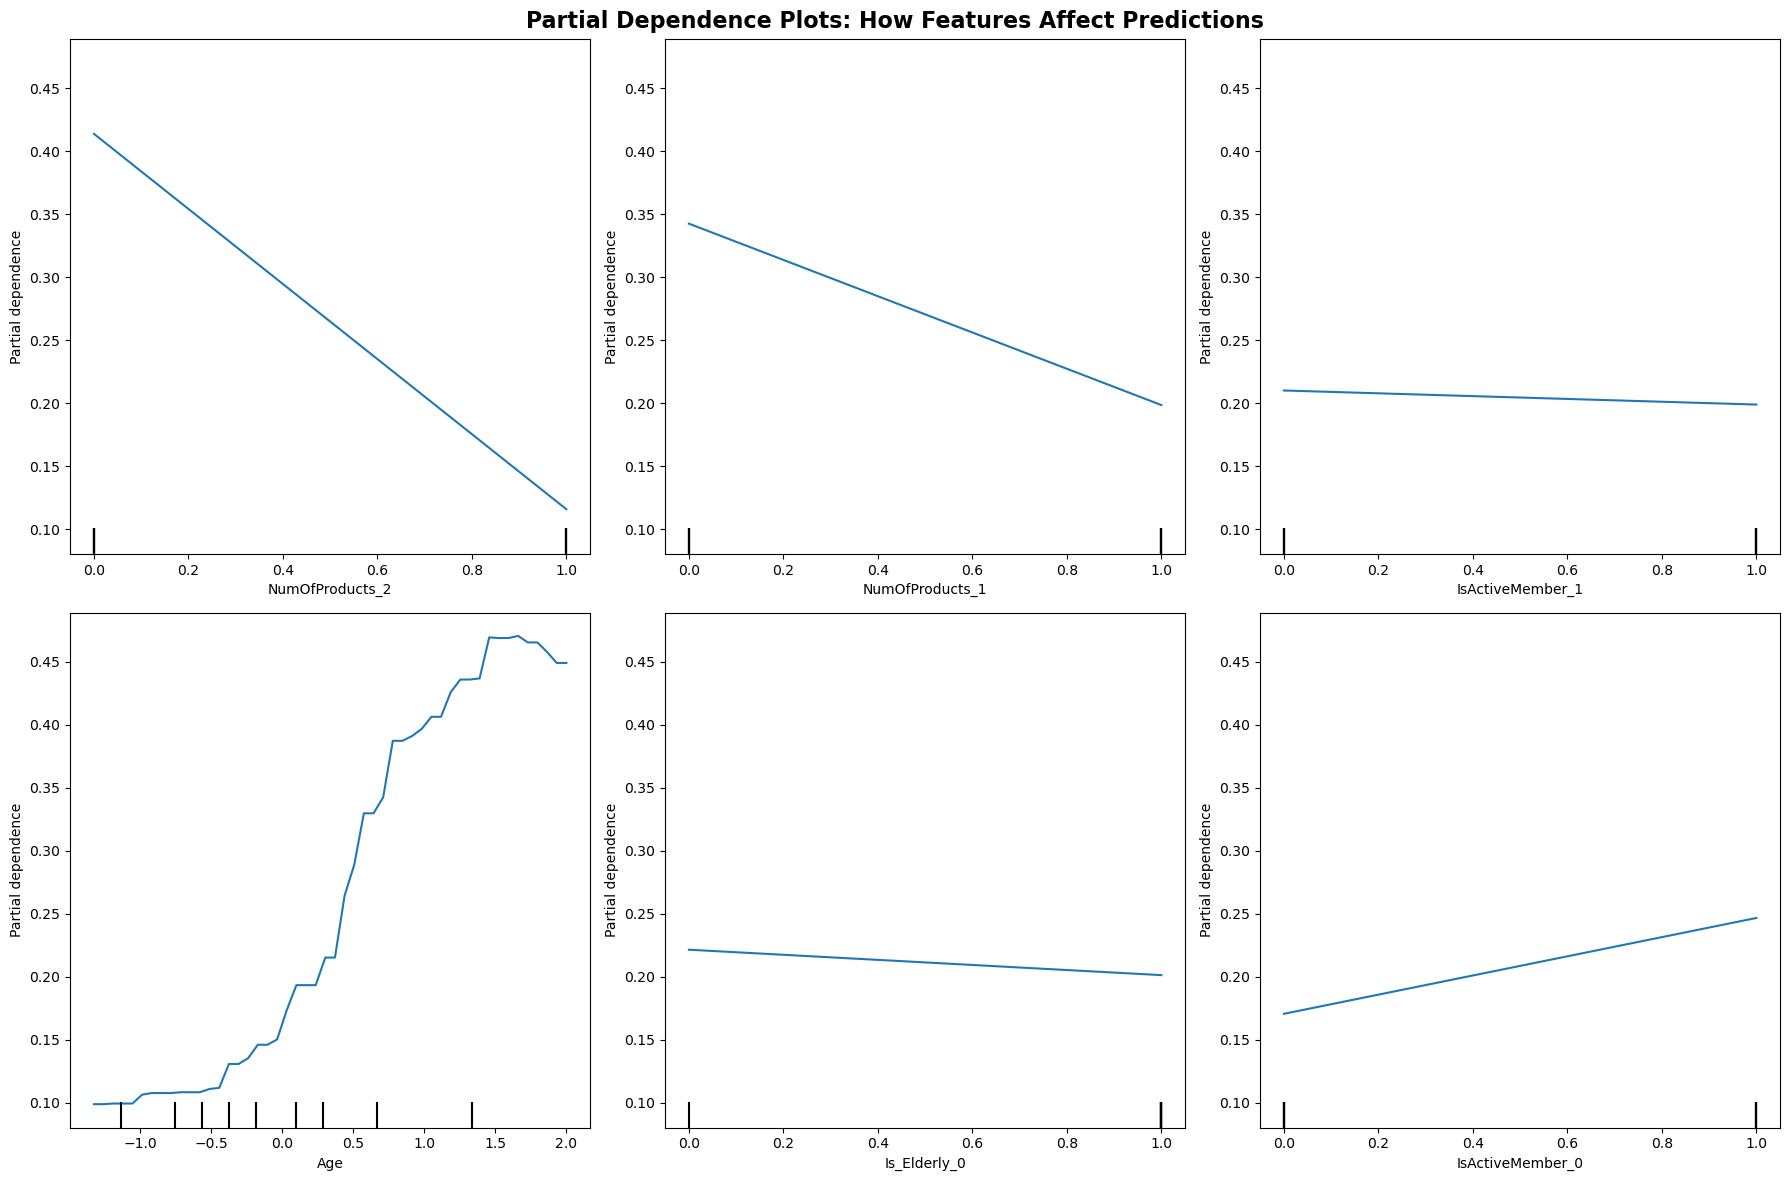


 Partial Dependence Plots Complete!


In [19]:

from sklearn.inspection import PartialDependenceDisplay

print("📈 PARTIAL DEPENDENCE PLOTS")
print("="*60)

# Select top features from importance
top_features = feature_importance_df['Feature'].head(6).tolist()
feature_indices = [list(feature_names).index(f) for f in top_features]

# Create PDP plots
fig, ax = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('Partial Dependence Plots: How Features Affect Predictions', 
             fontsize=16, fontweight='bold')

# Get the XGBoost model from ensemble
xgb_model = model_pipeline.named_steps['classifier'].estimators_[0]

# Create PDP display
display = PartialDependenceDisplay.from_estimator(
    xgb_model,
    X_transformed,
    features=feature_indices,
    feature_names=feature_names,
    grid_resolution=50,
    ax=ax.ravel(),
    kind='average'
)

plt.tight_layout()
plt.savefig('partial_dependence_plots.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n Partial Dependence Plots Complete!")

**Cell 11.5: Local Interpretability (LIME)**  
  Explains individual customer predictions to demonstrate localized model reasoning.

🔍 LIME Analysis (Simplified Version)

Customer 0:
Prediction: Churn
Top factors:
  NumOfProducts_2 <= 0.00: 0.293
  0.00 < NumOfProducts_1 <= 1.00: -0.169
  NumOfProducts_4 <= 0.00: -0.144
  NumOfProducts_3 <= 0.00: -0.103
  IsActiveMember_0 <= 0.00: -0.077
  Geography_Germany <= 0.00: -0.045
  0.00 < Gender_Female <= 1.00: 0.044
  0.00 < IsActiveMember_1 <= 1.00: -0.037


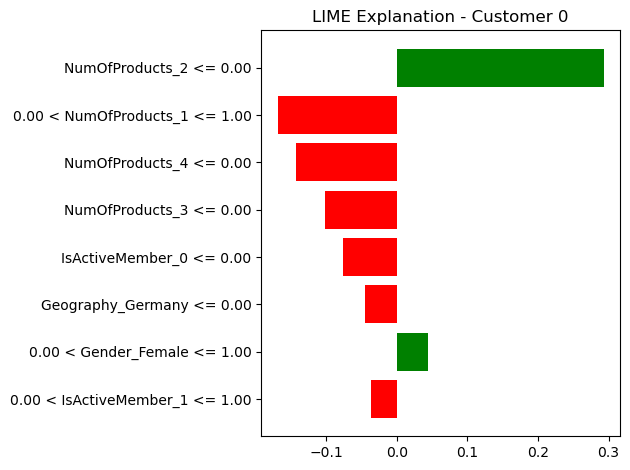

In [20]:

from lime.lime_tabular import LimeTabularExplainer
import matplotlib.pyplot as plt

print("🔍 LIME Analysis (Simplified Version)")

# preparing data for LIME (after feature engineering and preprocessing)
X_engineered = model_pipeline.named_steps['feature_engineer'].transform(X)
X_transformed = model_pipeline.named_steps['preprocessor'].transform(X_engineered)

if hasattr(X_transformed, 'toarray'):
    X_transformed = X_transformed.toarray()

#extracting feature names for LIME (numeric + one-hot encoded categorical)
feature_names = numeric_features + list(model_pipeline.named_steps['preprocessor']
                .transformers_[1][1]
                .named_steps['onehot']
                .get_feature_names_out(categorical_features))

# 2. LIME explainer
explainer = LimeTabularExplainer(
    X_transformed,
    feature_names=feature_names,
    class_names=['No Churn', 'Churn'],
    mode='classification',
    random_state=42
)

#explaining a single instance (customer)
idx = 0  # أول عينة
exp = explainer.explain_instance(
    X_transformed[idx],
    model_pipeline.named_steps['classifier'].predict_proba, 
    num_features=8
)

#showing the explanation in text format
print(f"\nCustomer {idx}:")
# using the classifier to predict the class for the instance (after transformation)
prediction = model_pipeline.named_steps['classifier'].predict([X_transformed[idx]])[0]
print(f"Prediction: {'Churn' if prediction == 1 else 'No Churn'}")
print("Top factors:")

# displaying the top features contributing to the prediction
for feature, weight in exp.as_list(): 
    print(f"  {feature}: {weight:.3f}")

#   visualizing the explanation
fig = exp.as_pyplot_figure()
plt.title(f'LIME Explanation - Customer {idx}')
plt.tight_layout()
plt.savefig('lime_explanation.png', dpi=300, bbox_inches='tight')
plt.show()

### Phase 7: Business Output & Submission


**Cell 12: Actionable Business Insights** 
  Translates algorithmic outputs into data-driven retention strategies for banking stakeholders.


In [21]:

print("BUSINESS INSIGHTS SUMMARY")
print("="*60)

# Extract SHAP values for analysis
if isinstance(shap_values, list):
    shap_array = shap_values[1]  # For class 1 (churn)
else:
    shap_array = shap_values

# Calculate average SHAP impact per feature
shap_impact = pd.DataFrame({
    'feature': feature_names,
    'impact': np.abs(shap_array).mean(axis=0),
    'direction': ['Positive' if shap_array[:, i].mean() > 0 else 'Negative' 
                  for i in range(len(feature_names))]
}).sort_values('impact', ascending=False)

print("\n TOP 5 CHURN RISK FACTORS (Increase Churn):")
risk_factors = shap_impact[shap_impact['direction'] == 'Positive'].head(5)
for idx, row in risk_factors.iterrows():
    print(f"   • {row['feature']}: +{row['impact']:.4f} impact")

print("\n TOP 5 RETENTION FACTORS (Decrease Churn):")
protective_factors = shap_impact[shap_impact['direction'] == 'Negative'].head(5)
for idx, row in protective_factors.iterrows():
    print(f"   • {row['feature']}: {row['impact']:.4f} impact")

print("\n CUSTOMER SEGMENTATION BASED ON RISK:")
# Create risk scores for training data
X_engineered_full = model_pipeline.named_steps['feature_engineer'].transform(X)
X_transformed_full = model_pipeline.named_steps['preprocessor'].transform(X_engineered_full)
risk_scores = model_pipeline.predict_proba(X)[:, 1]

# Define segments
segments = pd.DataFrame({
    'risk_score': risk_scores,
    'segment': pd.cut(risk_scores, 
                      bins=[0, 0.3, 0.6, 0.8, 1.0],
                      labels=['Low Risk', 'Medium Risk', 'High Risk', 'Very High Risk'])
})

segment_dist = segments['segment'].value_counts().sort_index()
print("\nCustomer Segments by Churn Risk:")
for segment, count in segment_dist.items():
    pct = (count/len(segments))*100
    print(f"   • {segment}: {count} customers ({pct:.1f}%)")

print("\n RECOMMENDED BUSINESS ACTIONS:")
print("   1. **Immediate Intervention**: Focus retention efforts on 'Very High Risk' segment")
print("   2. **Proactive Monitoring**: Implement early warning system for 'High Risk' customers")
print("   3. **Loyalty Programs**: Design special offers for customers with high Age, low Tenure")
print("   4. **Product Bundling**: Cross-sell to customers with low NumOfProducts")
print("   5. **Engagement Campaigns**: Target inactive members with re-engagement campaigns")

# Save insights
with open('business_insights.txt', 'w') as f:
    f.write("BUSINESS INSIGHTS FROM CHURN ANALYSIS\n")
    f.write("="*50 + "\n\n")
    f.write("Top Risk Factors:\n")
    for _, row in risk_factors.iterrows():
        f.write(f"- {row['feature']}: {row['impact']:.4f}\n")
    f.write("\nCustomer Segments:\n")
    for segment, count in segment_dist.items():
        f.write(f"- {segment}: {count}\n")

print("\n Business insights saved to 'business_insights.txt'")

BUSINESS INSIGHTS SUMMARY

 TOP 5 CHURN RISK FACTORS (Increase Churn):
   • NumOfProducts_1: +0.2452 impact
   • Balance_per_Product: +0.1640 impact
   • EstimatedSalary: +0.0729 impact
   • Geography_Spain: +0.0111 impact

 TOP 5 RETENTION FACTORS (Decrease Churn):
   • NumOfProducts_2: 0.9375 impact
   • Age: 0.7542 impact
   • IsActiveMember_0: 0.2690 impact
   • Geography_Germany: 0.2451 impact
   • Gender_Female: 0.2002 impact

 CUSTOMER SEGMENTATION BASED ON RISK:

Customer Segments by Churn Risk:
   • Low Risk: 5833 customers (58.3%)
   • Medium Risk: 2469 customers (24.7%)
   • High Risk: 882 customers (8.8%)
   • Very High Risk: 816 customers (8.2%)

 RECOMMENDED BUSINESS ACTIONS:
   1. **Immediate Intervention**: Focus retention efforts on 'Very High Risk' segment
   2. **Proactive Monitoring**: Implement early warning system for 'High Risk' customers
   3. **Loyalty Programs**: Design special offers for customers with high Age, low Tenure
   4. **Product Bundling**: Cross-se

**Cell 13: Project Summary**  
  Consolidates validation scores and methodological justifications.

 FINAL RESULTS SUMMARY

 MODEL PERFORMANCE SUMMARY
              Model CV Mean ROC AUC CV Std ROC AUC Test ROC AUC Log Loss Brier Score PR-AUC
Ensemble (7 models)          0.8690         0.0062       0.8685   0.3870      0.1195 0.7168

 Results saved to 'model_performance_summary.csv'


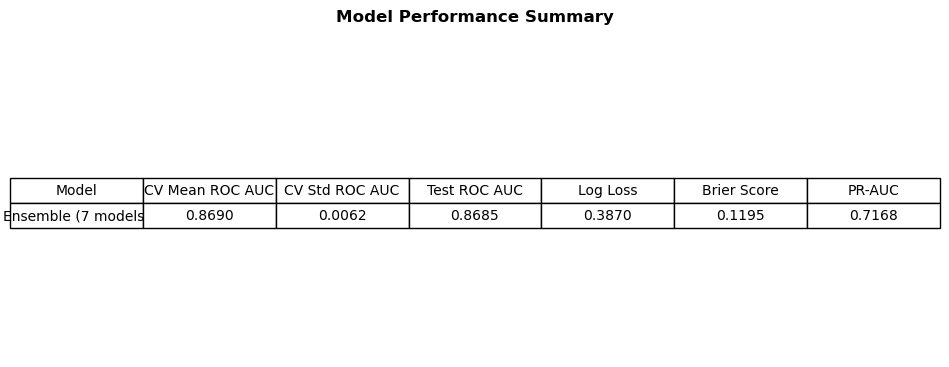

In [22]:

print(" FINAL RESULTS SUMMARY")
print("="*60)

# Collect all metrics
results = []

# 1. Cross-validation results
results.append({
    'Model': 'Ensemble (7 models)',
    'CV Mean ROC AUC': f"{np.mean(auc_scores):.4f}",
    'CV Std ROC AUC': f"{np.std(auc_scores):.4f}",
    'Test ROC AUC': f"{final_score:.4f}",
    'Log Loss': f"{logloss:.4f}",
    'Brier Score': f"{brier:.4f}",
    'PR-AUC': f"{pr_auc:.4f}"
})

# 2. Individual model performance (optional)
# You can add individual model scores here

# Create DataFrame
results_df = pd.DataFrame(results)

print("\n MODEL PERFORMANCE SUMMARY")
print(results_df.to_string(index=False))

# Save to CSV
results_df.to_csv('model_performance_summary.csv', index=False)
print("\n Results saved to 'model_performance_summary.csv'")

# Create visualization
fig, ax = plt.subplots(figsize=(10, 4))
ax.axis('tight')
ax.axis('off')
table = ax.table(cellText=results_df.values,
                 colLabels=results_df.columns,
                 cellLoc='center',
                 loc='center')
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2, 1.5)
plt.title('Model Performance Summary', fontweight='bold', pad=20)
plt.savefig('performance_summary.png', dpi=300, bbox_inches='tight')
plt.show()

**Cell 14: Final Programmatic Submission** 
  Generates the final `final_submission.csv` containing raw continuous probability scores, strictly formatted for Kaggle evaluation.


In [23]:
#FINAL SUBMISSION CREATION  
print("Finalizing Submission...")


model_pipeline.fit(X, y)


final_probs = model_pipeline.predict_proba(X)[:, 1]

#CREATING THE FINAL SUBMISSION FILE
submission = pd.DataFrame({
    'CustomerId': df['CustomerId'] if 'CustomerId' in df.columns else df.index,
    'churn': final_probs 
})

#SAVING THE FINAL SUBMISSION FILE
submission.to_csv('final_submission.csv', index=False)

print("-" * 30)
print("!!!! CONGRATULATIONS! Project is Complete.!!!!")
print("! Created: final_submission.csv")
print("! Created: Feature Importance Plot")



Finalizing Submission...
------------------------------
!!!! CONGRATULATIONS! Project is Complete.!!!!
! Created: final_submission.csv
! Created: Feature Importance Plot
